In [ ]:
import json
import torch
from transformer_lens.train import train
from transformer_lens.train import HookedTransformerTrainConfig
from src.utils import load_model, ABSAAutoRegressiveDataset
from src.utils import apply_active_edge_unfreezing
import argparse
from datetime import datetime
import os
import pickle
from time import time
from copy import deepcopy
os.chdir('..')

/raid/home/m13521157/absa-eap-ig/enveap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Check length of each instance in the dataset + remove data with length > max_len

In [2]:
# === Set Device ===
if torch.backends.mps.is_available():
	device = 'mps'
elif torch.cuda.is_available():
	device = 'cuda'
else:
	device = 'cpu'


# === Load Model ===
model = load_model('Qwen/Qwen2.5-0.5B', device=device)

Loading base TransformerLens model: Qwen/Qwen2.5-0.5B...


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


In [3]:
datasets = {}
dataset_folder = 'clean_train2500'
lang = 'indo'
for lang in ['eng', 'sunda', 'indo']:
	datasets[lang] = {}
	for split in ['train', 'dev', 'test']:
		reasoning_suffix = '_noreasoning' if split == 'train' else ''
		dataset_path = f'hotel_dataset/{lang}/{dataset_folder}/hotel_aste_{split}_augmented{reasoning_suffix}.json'
		with open(dataset_path) as f:
			datasets[lang][split] = json.load(f)

In [4]:
# === Load Dataset ===
max_len = 300
dataset_objects = {}
for lang in ['eng', 'sunda', 'indo']:
	dataset_objects[lang] = {}
	for split in ['train', 'dev', 'test']:
		dataset_objects[lang][split] = ABSAAutoRegressiveDataset(
			deepcopy(datasets[lang][split]),
			model.tokenizer,
			shuffle=True,
			seed=1,
			sample_size=None,
			max_len=max_len
		)


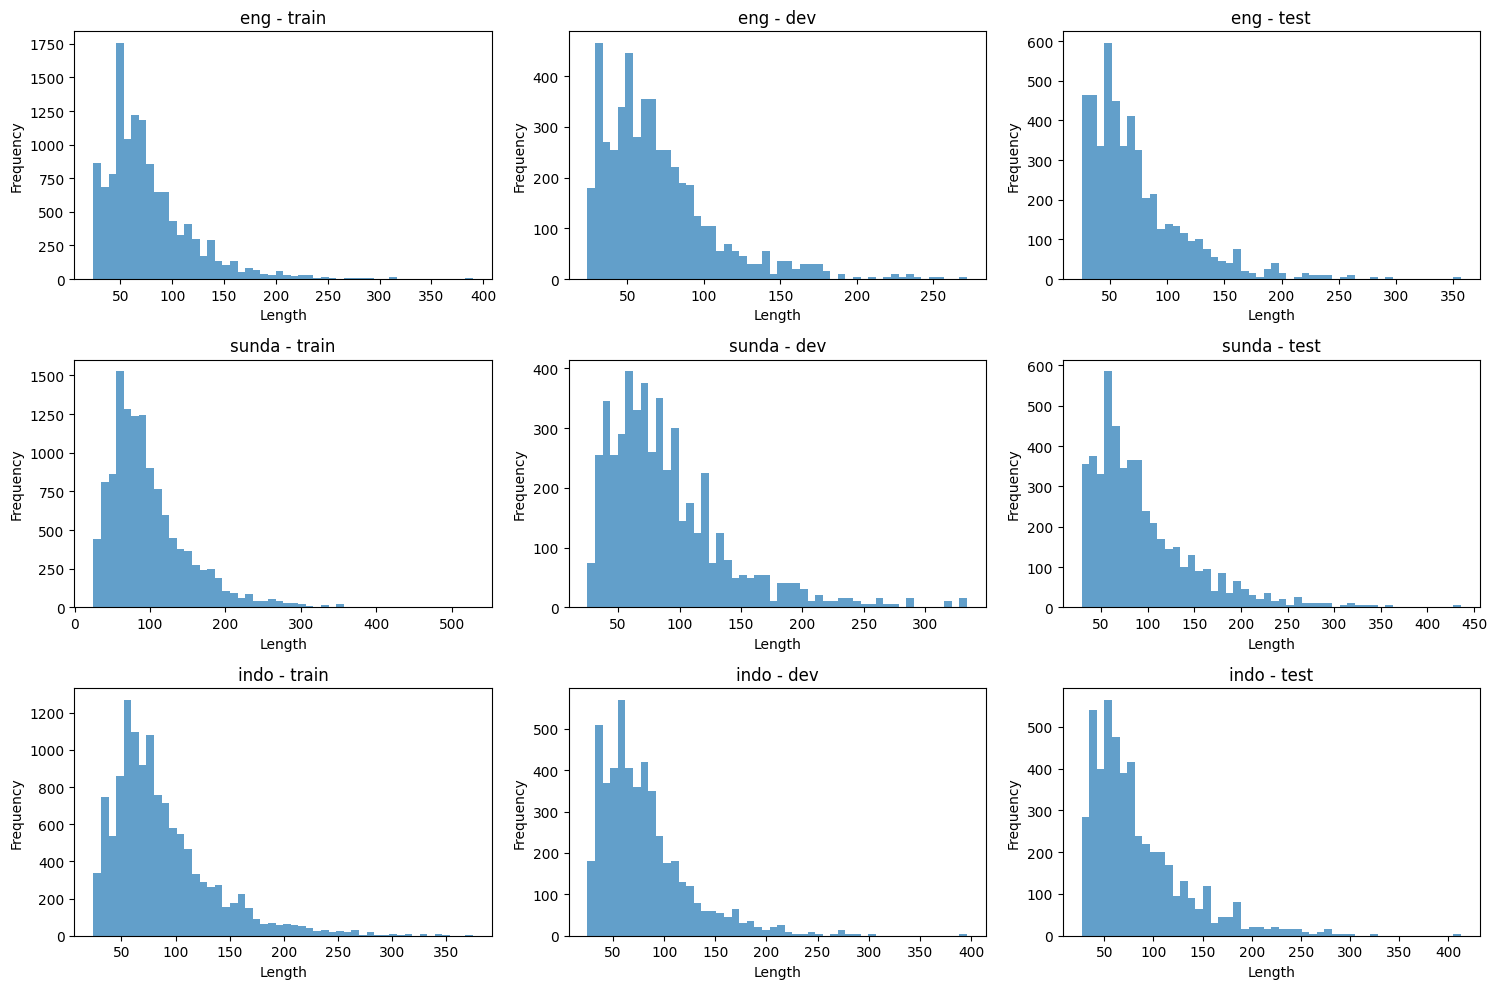

In [10]:
lengths = {}
for lang in datasets:
	lengths[lang] = {}
	for split in datasets[lang]:
		lengths[lang][split] = []
		absa_data = datasets[lang][split]
		for instance in absa_data:
			final_str = instance['input'] + ' ' + instance['target'] + model.tokenizer.eos_token
			lengths[lang][split].append(len(model.tokenizer(final_str)['input_ids']))

# Plot histogram of lengths, use subplot 3 row 3 columns, columns for split, rows is language, Use for loop
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
for i, lang in enumerate(lengths):
	for j, split in enumerate(lengths[lang]):
		ax = axs[i, j]
		ax.hist(lengths[lang][split], bins=50, alpha=0.7)
		ax.set_title(f'{lang} - {split}')
		ax.set_xlabel('Length')
		ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [11]:
print(f"Max length: {max_len} tokens")
for lang in ['eng', 'sunda', 'indo']:
	count_eos = 0
	for idx, i in enumerate(dataset_objects[lang]['train']):
		last_tokens = i['tokens'][-1]
		if last_tokens != model.tokenizer.eos_token_id:
			# print(f"Dataset {idx} has no eos token at the end")
			# print(model.to_string(i['tokens']))
			count_eos += 1
	print(f"Total truncated instances in {lang} dataset: {count_eos}/{len(dataset_objects[lang]['train'])}")

Max length: 300 tokens
Total truncated instances in eng dataset: 0/12500
Total truncated instances in sunda dataset: 0/12500
Total truncated instances in indo dataset: 0/12500


In [5]:
truncated_indexes = {
	'eng': set(),
	'sunda': set(),
	'indo': set()
}
max_len = 300
print(f"Max length: {max_len} tokens")
for lang in ['eng', 'sunda', 'indo']:
	count_eos = 0
	for idx, i in enumerate(datasets[lang]['train']):
		final_str = i['input'].strip() + ' ' + i['target'].strip() + model.tokenizer.eos_token
		if len(model.tokenizer(final_str)['input_ids']) > max_len:
			# print(f"Dataset {lang} {i['sentence_id']} {i['instance_id']} has length greater than max_len")
			count_eos += 1
			truncated_indexes[lang].add(i['sentence_id'])
	print(f"Total truncated instances in {lang} dataset: {count_eos}/{len(datasets[lang]['train'])}")

Max length: 300 tokens
Total truncated instances in eng dataset: 20/12500
Total truncated instances in sunda dataset: 90/12500
Total truncated instances in indo dataset: 50/12500


In [6]:
combined_truncated_indexes = set()
for lang in truncated_indexes:
	combined_truncated_indexes = combined_truncated_indexes.union(truncated_indexes[lang])
len(combined_truncated_indexes)

18

In [9]:
datasets['indo'].keys()

dict_keys(['train', 'dev', 'test'])

In [10]:
# Create new datasets with truncated instances removed
new_datasets = {}
for lang in ['eng', 'sunda', 'indo']:
	new_datasets[lang] = {
		'train': [],
		'dev': deepcopy(datasets[lang]['dev']),
		'test': deepcopy(datasets[lang]['test'])
	}
	for instance in datasets[lang]['train']:
		if instance['sentence_id'] not in combined_truncated_indexes:
			new_datasets[lang]['train'].append(deepcopy(instance))

In [ ]:
# # Reset the sentence_id and instance_id in the new datasets
# # Sentence_id add per 5 instances, instance_id always increments by 1
# for lang in ['eng', 'sunda', 'indo']:
# 	current_sentence_id = 0
# 	current_instance_id = 0
# 	for split in ['train', 'dev', 'test']:
# 		for instance in new_datasets[lang][split]:
# 			instance['sentence_id'] = current_sentence_id
# 			instance['instance_id'] = current_instance_id
# 			current_instance_id += 1
# 			if (current_instance_id % 5) == 0:
# 				current_sentence_id += 1

In [11]:
len(new_datasets['indo']['train']), len(new_datasets['eng']['train']), len(new_datasets['sunda']['train'])

(12410, 12410, 12410)

In [12]:
print(f"{new_datasets['indo']['train'][5005]}\n{new_datasets['eng']['train'][5005]}\n{new_datasets['sunda']['train'][5005]}")

{'sentence_id': 1007, 'instance_id': 5035, 'task_elements': 'aos', 'input': 'pemandangan nya keren , bagus tetapi agak spooky iya . seram kalau malam . [A] [O] [S]', 'target': '[A] pemandangan nya [O] keren [S] positive [SSEP] [A] pemandangan nya [O] bagus [S] positive [SSEP] [A] pemandangan nya [O] agak spooky [S] negative', 'element_order': 'aos'}
{'sentence_id': 1007, 'instance_id': 5035, 'task_elements': 'aos', 'input': 'the view is cool , nice but a bit spooky , yes . scary at night . [A] [O] [S]', 'target': '[A] view [O] cool [S] positive [SSEP] [A] view [O] nice [S] positive [SSEP] [A] view [O] a bit spooky [S] negative', 'element_order': 'aos'}
{'sentence_id': 1007, 'instance_id': 5035, 'task_elements': 'aos', 'input': 'pamandanganna keren , alus ngan rada pikasieuneun kitu . sieun mun peuting . [A] [O] [S]', 'target': '[A] pamandanganna [O] keren [S] positive [SSEP] [A] pamandanganna [O] alus [S] positive [SSEP] [A] pamandanganna [O] rada pikasieuneun [S] negative', 'element_o

In [13]:
# Save new_datasets to new path
dataset_folder = 'clean_traintruncated'
for lang in ['eng', 'sunda', 'indo']:
	for split in ['train', 'dev', 'test']:
		reasoning_suffix = '_noreasoning' if split == 'train' else ''
		new_dataset_path = f'hotel_dataset/{lang}/{dataset_folder}/hotel_aste_{split}_augmented{reasoning_suffix}.json'
		os.makedirs(os.path.dirname(new_dataset_path), exist_ok=True)
		with open(new_dataset_path, 'w') as f:
			json.dump(new_datasets[lang][split], f, indent=4, ensure_ascii=False)

In [4]:
# Test new absa dataset
sample = [{
    'input': 'The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.The hotel was great, but the service was terrible.',
    'target': 'The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.The carpet was dirty, the room was small, and the food was bad.',
}]
max_len = 256
absa_dataset_sample = ABSAAutoRegressiveDataset(
    sample,
	model.tokenizer,
	shuffle=True,
	seed=1,
	sample_size=None,
	max_len=max_len
)

print(absa_dataset_sample[0]['tokens'].shape)
print(absa_dataset_sample[0])

torch.Size([256])
{'tokens': tensor([   785,   9500,    572,   2244,     11,    714,    279,   2473,    572,
         17478,  11568,   9500,    572,   2244,     11,    714,    279,   2473,
           572,  17478,  11568,   9500,    572,   2244,     11,    714,    279,
          2473,    572,  17478,  11568,   9500,    572,   2244,     11,    714,
           279,   2473,    572,  17478,  11568,   9500,    572,   2244,     11,
           714,    279,   2473,    572,  17478,  11568,   9500,    572,   2244,
            11,    714,    279,   2473,    572,  17478,  11568,   9500,    572,
          2244,     11,    714,    279,   2473,    572,  17478,  11568,   9500,
           572,   2244,     11,    714,    279,   2473,    572,  17478,  11568,
          9500,    572,   2244,     11,    714,    279,   2473,    572,  17478,
         11568,   9500,    572,   2244,     11,    714,    279,   2473,    572,
         17478,  11568,   9500,    572,   2244,     11,    714,    279,   2473,
           

In [5]:
# Get all elements except the last one
print(absa_dataset_sample[0]['tokens'][:-1].shape)  # This will remove the

torch.Size([255])


In [6]:
# Test new absa dataset
sample = [{
    'input': 'The hotel was great',
    'target': 'The carpet was dir',
}]
max_len = 256
absa_dataset_sample = ABSAAutoRegressiveDataset(
    sample,
	model.tokenizer,
	shuffle=True,
	seed=1,
	sample_size=None,
	max_len=max_len
)

print(absa_dataset_sample[0]['tokens'].shape)
print(absa_dataset_sample[0])

torch.Size([256])
{'tokens': tensor([   785,   9500,    572,   2244,    576,  27854,    572,   5419, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643, 151643,
        151

In [41]:
model.to_string(model.tokenizer.pad_token_id)

'<|endoftext|>'

### Merge dev and test datasets

In [2]:
dataset_folder = 'clean_traintruncated'
for lang in ['eng', 'sunda', 'indo']:
	dataset_path_dev = f'hotel_dataset/{lang}/{dataset_folder}/hotel_aste_dev_augmented.json'
	dataset_path_test = f'hotel_dataset/{lang}/{dataset_folder}/hotel_aste_test_augmented.json'
	with open(dataset_path_dev) as f:
		dataset_dev = json.load(f)
	with open(dataset_path_test) as f:
		dataset_test = json.load(f)
	# Merge dev and test datasets
	merged_dataset = dataset_dev + dataset_test
	# Save merged dataset
	merged_dataset_path = f'hotel_dataset/{lang}/{dataset_folder}/hotel_aste_dev_test_augmented.json'
	os.makedirs(os.path.dirname(merged_dataset_path), exist_ok=True)
	with open(merged_dataset_path, 'w') as f:
		json.dump(merged_dataset, f, indent=4, ensure_ascii=False)
